# Binärgewitter 2025

Tagline?
Let's take a look:
Zuerst müssen wir alle librarys importieren und Daten laden.

In [1]:
import pandas as pd
import datetime
import calmap

In [2]:
year = 2025

In [3]:
podcasts = pd.read_csv(f"data/{year}.csv", sep=",")

In [4]:
def parse_duration(duration_str):
    hours, minutes, seconds = map(int, duration_str.split(':'))
    return datetime.timedelta(hours=hours, minutes=minutes, seconds=seconds)

In [5]:
podcasts["Duration"] = podcasts["Duration"].transform(parse_duration)
podcasts["Record Date"] = podcasts["Record Date"].transform(datetime.date.fromisoformat)
podcasts["Release Date"] = podcasts["Release Date"].transform(datetime.date.fromisoformat)

## Übersicht

Diese Jahr habe wir einige Sendungen veröffentlicht:

In [6]:
talk = podcasts[podcasts.Type == "Talk"]
westcoast = podcasts[podcasts.Type == "Westcoast"]

In [7]:
print(f"Talk:      {len(talk)}")
print(f"Westcoast: {len(westcoast)}")
print(f"Total:     {len(podcasts)}")

Talk:      22
Westcoast: 0
Total:     22


Mit 22 sind es gleich viele wie letztes Jahr und auch fuer 2026 haben wir uns vorgenommen aehnlich viele Podcast aufzunehmen.

## Binärgewitter Talk

In [8]:
year_length =  datetime.date(year+1, 1, 1) - datetime.date(year, 1, 1)  # works for leap years, too
print(f"Für Binärgewitter Talk sind das alle {(year_length / len(talk)).days} Tage eine Sendung.")

Für Binärgewitter Talk sind das alle 16 Tage eine Sendung.


Wir schauen uns nun die Binärgewitter Talk Sendungen genauer an.

In [9]:
talk.loc[:, (talk != 0).any(axis=0)]  # alle hosts auslassen, die nie da waren

,Name,Release Date,Record Date,Type,Duration,ingo,l33tname,madmas,makefu
0,Binärgewitter Talk #372: Sondersendung,2025-12-30,2025-12-29,Talk,0 days 01:42:25,1,1,1,1
1,Binärgewitter Talk #371: Bei Stromausfall zerf...,2025-12-23,2025-12-22,Talk,0 days 02:46:50,1,0,1,1
2,Binärgewitter Talk #370: Ein Skibidi Rizz,2025-11-16,2025-11-14,Talk,0 days 02:54:23,1,1,1,1
3,Binärgewitter Talk #369: Netzgeld,2025-10-31,2025-10-30,Talk,0 days 01:03:31,1,0,1,0
4,Binärgewitter Talk #368: Raspi in Öl,2025-10-19,2025-10-17,Talk,0 days 03:48:20,0,0,1,1
5,Binärgewitter Talk #367: Da bist du nicht dabei,2025-09-30,2025-09-29,Talk,0 days 02:35:53,1,0,1,1
6,Binärgewitter Talk #366: 3 Stunden Spaß im Wald,2025-09-06,2025-09-04,Talk,0 days 02:39:41,0,1,0,1
7,Binärgewitter Talk #365: Daten im Boden lassen,2025-08-17,2025-08-16,Talk,0 days 01:37:09,1,0,1,0
8,Binärgewitter Talk #364: Seilbahn statt Stau,2025-08-08,2025-08-07,Talk,0 days 01:41:28,0,1,1,0
9,Binärgewitter Talk #363: Drop-Shipping für Dom...,2025-07-26,2025-07-25,Talk,0 days 02:33:55,1,1,0,1


### Sendungen pro Host:

In [10]:
podcasters = ["ingo", "l33tname", "madmas", "makefu"]
teilnahmen_pro_host = podcasts[podcasters].sum()
sendezeit_pro_host = podcasts[podcasters].apply(lambda anwesenheit: (anwesenheit * podcasts['Duration']).sum())

pd.DataFrame({
    "Episodenzahl": teilnahmen_pro_host,
    "Episodenzahl Anteil in %": (100 * teilnahmen_pro_host / len(podcasts)) .astype(int),
    "Sendezeit": sendezeit_pro_host,
    "Sendezeit Anteil in %": (100 * sendezeit_pro_host / podcasts["Duration"].sum()).astype(int),
})


,Episodenzahl,Episodenzahl Anteil in %,Sendezeit,Sendezeit Anteil in %
ingo,16,72,1 days 13:17:55,70
l33tname,16,72,1 days 14:25:23,72
madmas,17,77,1 days 16:59:45,76
makefu,19,86,2 days 00:52:34,91


Niemand war für alle Sendungen hier, alle haben die eine oder andere Sendung verpasst.

### Duration

Da der Feed jetzt eine duration pro Sendung angibt kann man jetzt auch interessante Auswertungen machen.

In [11]:
durations = podcasts["Duration"]

In [12]:
print(f"""
Unsere totale Sendezeit war dieses Jahr {durations.sum()}.
Die Sendung dauerten zwischen {durations.min()} und {durations.max()},
im Schnitt {durations.mean()}, im median {durations.median()}.
""")


Unsere totale Sendezeit war dieses Jahr 2 days 05:14:42.
Die Sendung dauerten zwischen 0 days 01:03:31 und 0 days 03:48:20,
im Schnitt 0 days 02:25:12.818181818, im median 0 days 02:30:21.500000.



Hier sind ein paar lieblos hingeklatschte Statistiken zur Sendezeit.

In [13]:
durations.describe()

count                           22
mean     0 days 02:25:12.818181818
std      0 days 00:35:58.606707519
min                0 days 01:03:31
25%         0 days 02:07:13.750000
50%         0 days 02:30:21.500000
75%         0 days 02:45:36.750000
max                0 days 03:48:20
Name: Duration, dtype: object

Hier sind die kürzeste und die längste Episode des Jahres.

In [14]:
pd.concat([
    podcasts.loc[durations.idxmin()],
    podcasts.loc[durations.idxmax()]
], axis=1).T

,Name,Release Date,Record Date,Type,Duration,ingo,l33tname,madmas,makefu,pfleidi,marc
3,Binärgewitter Talk #369: Netzgeld,2025-10-31,2025-10-30,Talk,0 days 01:03:31,1,0,1,0,0,0
4,Binärgewitter Talk #368: Raspi in Öl,2025-10-19,2025-10-17,Talk,0 days 03:48:20,0,0,1,1,0,0


### Recording datum

Hier sehen wir, an welchen Tagen wir aufnehmen.

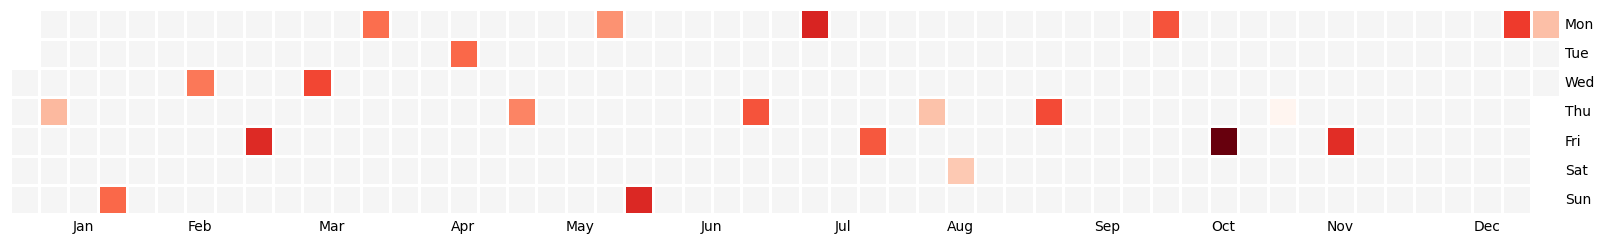

In [15]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=20,20


release_date = talk
talk['Duration_sec'] = release_date['Duration'].values.astype("float64")

release_date.index = pd.to_datetime(release_date["Record Date"], format="%Y-%m-%d")
calmap.yearplot(release_date['Duration_sec']);

## Bearbeitungszeit

Wie viele Tage sind zwischen Aufzeichnung und Release vergangen?

In [16]:
podcasts["Delay"] = delays = podcasts["Release Date"]-podcasts["Record Date"]

<Axes: title={'center': 'Bearbeitungszeit'}, ylabel='Frequency'>

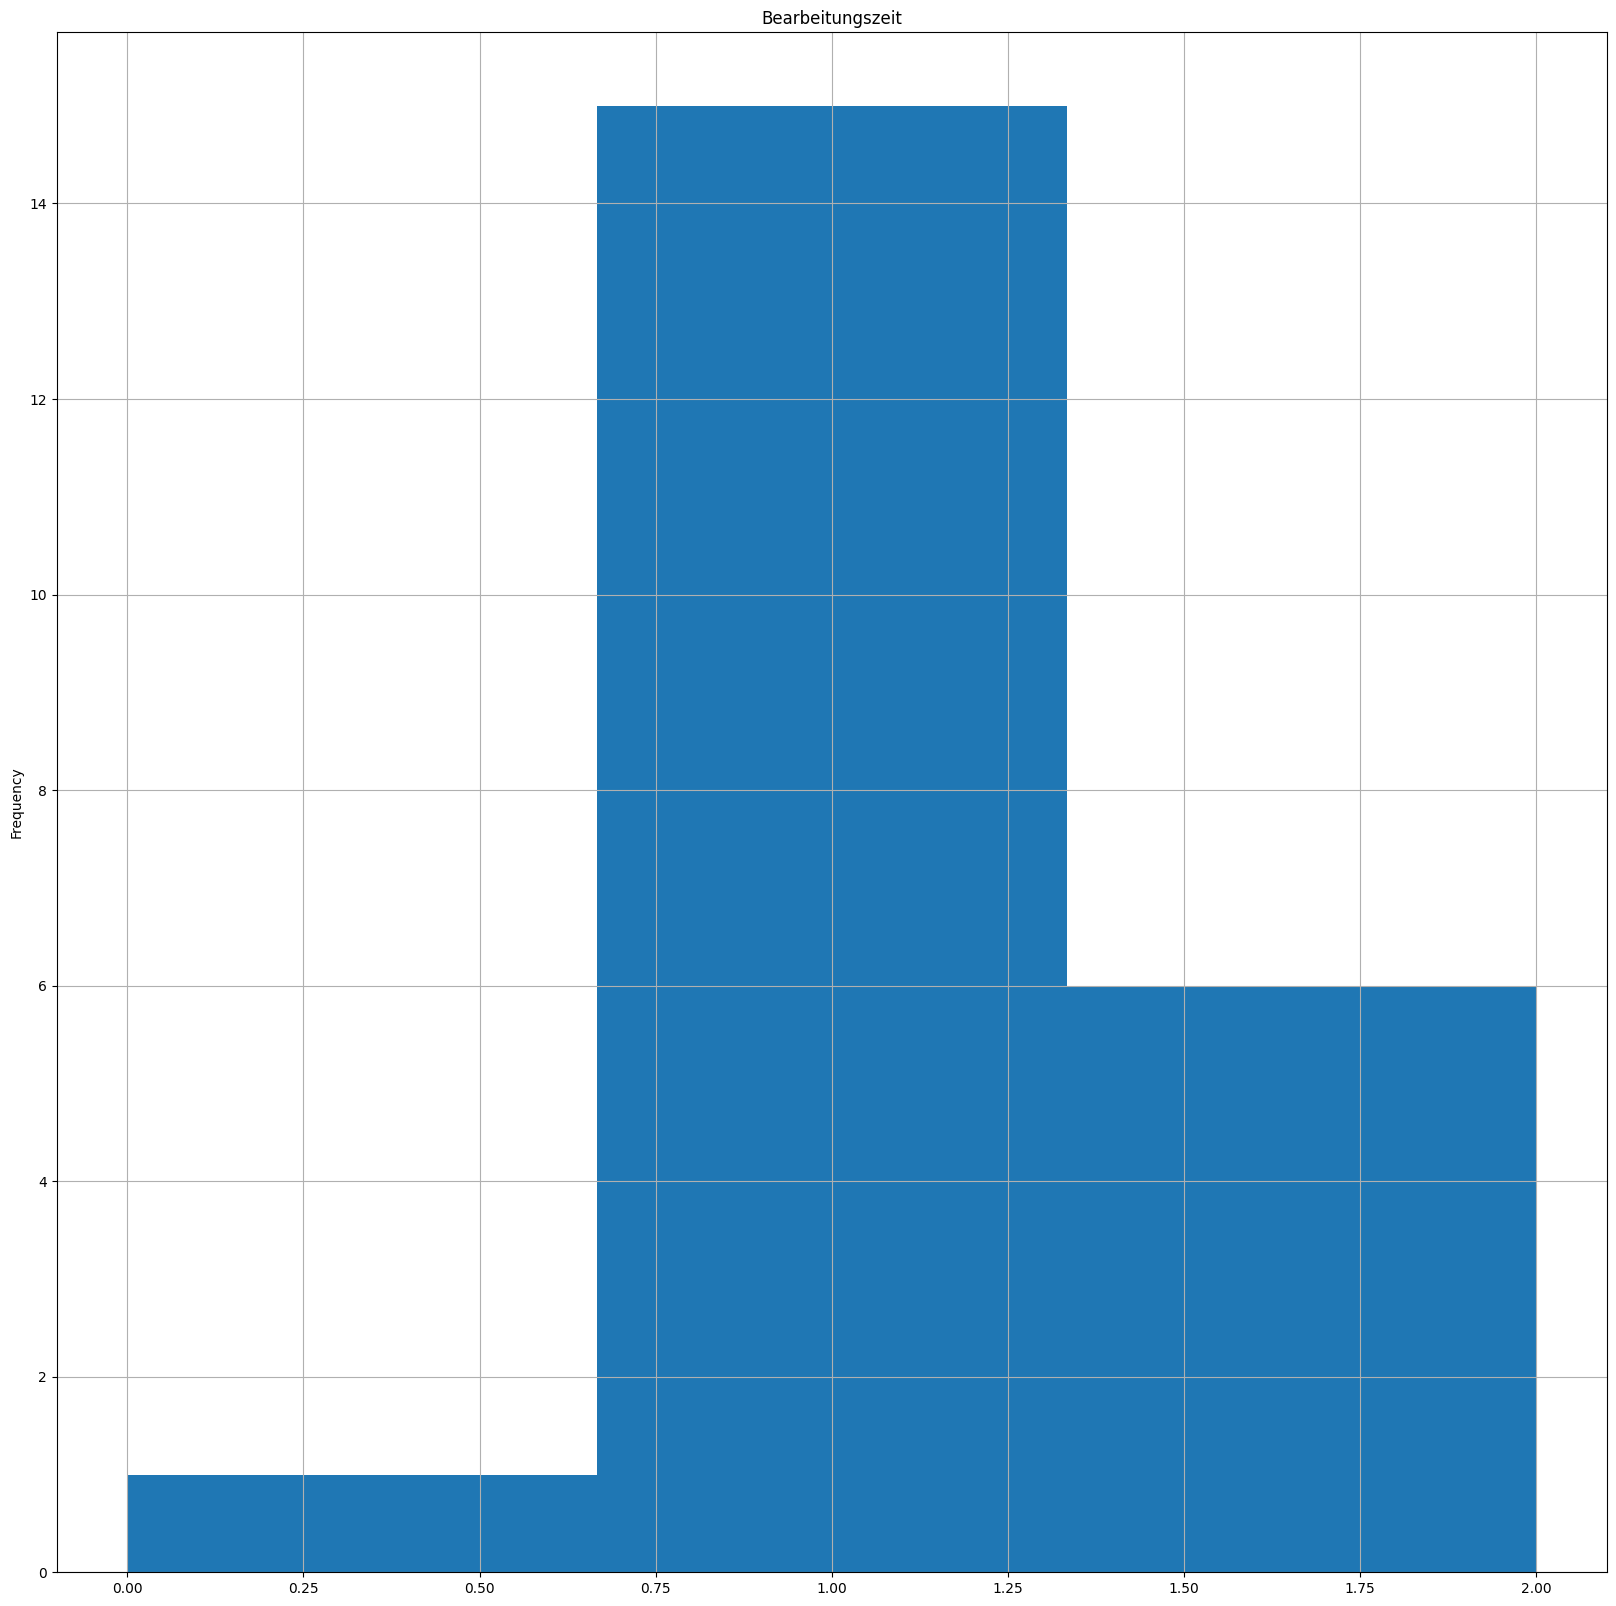

In [17]:
delays.transform(lambda delay: delay.days).plot(
    kind='hist',
    title="Bearbeitungszeit",
    bins=1 + (delays.max() - delays.min()).days,
    grid=True
)